<a href="https://colab.research.google.com/github/vyron-arvanitis/pytorch_tutorials/blob/main/02_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Make classification dat aand get it ready

In [1]:
import sklearn
sklearn.__version__

'1.6.1'

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.05,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.74220688  0.24668576]
 [-0.7340323   0.16869164]
 [-0.82985872  0.22195899]
 [-0.42913559  0.67223019]
 [ 0.44560223 -0.89493556]]
First 5 samples of y:
 [1 1 1 1 0]


In [5]:
# Number of features
X.shape[1]

2

In [42]:
# MAke DataFrame of circles
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:, 1],
                        "label": y
                        }
                       )
circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1.0
1,-0.734032,0.168692,1.0
2,-0.829859,0.221959,1.0
3,-0.429136,0.672230,1.0
4,0.445602,-0.894936,0.0
5,-0.469885,0.708037,1.0
6,-0.016045,0.805623,1.0
7,0.759623,0.159526,1.0
8,-0.175692,-0.799837,1.0
9,-0.110616,1.042207,0.0


In [44]:
circles.label.value_counts()

,count
label,
1.0,500
0.0,500


In [40]:
circles.X1

,X1
0,0.742207
1,-0.734032
2,-0.829859
3,-0.429136
4,0.445602
...,...
995,0.249091
996,-0.985370
997,-0.128231
998,0.660905


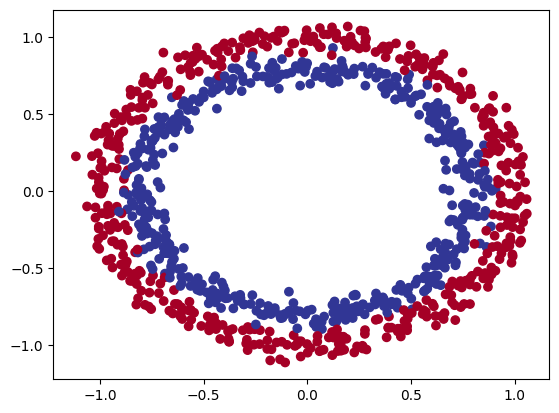

In [7]:
# Visualize the data!
import matplotlib.pyplot as plt
plt.scatter(x=circles["X1"],
            y=circles["X2"],
            c=circles["label"],
            cmap=plt.cm.RdYlBu)

### Check input and output shapes

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X: [0.74220688 0.24668576] and the same for y:1
Shapes for one sample of X: (2,) and the same for y:()


### Turn data into tensors and train_test_splits

In [10]:
import torch

In [11]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [12]:
X

tensor([[ 0.7422,  0.2467],
        [-0.7340,  0.1687],
        [-0.8299,  0.2220],
        ...,
        [-0.1282, -0.8261],
        [ 0.6609, -0.7932],
        [ 0.2784,  0.9674]])

In [13]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [14]:
# Split data into train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    shuffle=True)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

## Build a model

In [15]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
# Construc a model
class CircleModelV1(nn.Module):
  def __init__(self, in_feature: int):
    super().__init__()

    layers = []
    layers.append(nn.Linear(in_features=in_feature, out_features=5))
    layers.append(nn.Linear(in_features=5, out_features=1))
    self.sequential= nn.Sequential(*layers)

  def forward(self, x: torch.Tensor):
    return self.sequential(x)

model_0 = CircleModelV1(in_feature=X_train.shape[1]).to(device)
model_0

CircleModelV1(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [17]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [18]:
model_0.state_dict()

OrderedDict([('sequential.0.weight',
              tensor([[ 0.2401,  0.1795],
                      [-0.3893, -0.2238],
                      [ 0.2745, -0.0961],
                      [ 0.6804, -0.2193],
                      [ 0.1928, -0.3536]], device='cuda:0')),
             ('sequential.0.bias',
              tensor([ 0.0187,  0.3721, -0.1628,  0.0879, -0.3149], device='cuda:0')),
             ('sequential.1.weight',
              tensor([[ 0.3061,  0.0304,  0.3003, -0.0770,  0.1943]], device='cuda:0')),
             ('sequential.1.bias', tensor([0.0550], device='cuda:0'))])

In [19]:
model_0.state_dict()["sequential.0.weight"], model_0.state_dict().keys()

(tensor([[ 0.2401,  0.1795],
         [-0.3893, -0.2238],
         [ 0.2745, -0.0961],
         [ 0.6804, -0.2193],
         [ 0.1928, -0.3536]], device='cuda:0'),
 odict_keys(['sequential.0.weight', 'sequential.0.bias', 'sequential.1.weight', 'sequential.1.bias']))

In [20]:
# Make untrained predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples {len(X_test)}, Shape: {X_test.shape}")
print(f"First 10 predictions:\n {untrained_preds[:10]}")
print(f"Frist 10 predictions rounded:\n {torch.round(untrained_preds[:10])}")
print(f"First 10 labels :\n {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples 200, Shape: torch.Size([200, 2])
First 10 predictions:
 tensor([[-0.1135],
        [-0.0675],
        [-0.1235],
        [-0.1094],
        [ 0.0306],
        [ 0.0582],
        [ 0.0511],
        [ 0.0804],
        [-0.1284],
        [-0.0697]], device='cuda:0')
Frist 10 predictions rounded:
 tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.],
        [-0.]], device='cuda:0')
First 10 labels :
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Setup loss functio nand otpimizer

In [21]:
# setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = requrie inputs to have gone through the sigmoid activation function prior to the input BCELoss
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.02)

In [22]:
# Calculate teh accuracy

def accuracy_fn(y_true, y_pred):
  return 100*(torch.eq(y_true, y_pred).sum().item())/len(y_pred)

## Train model

### Going form raw logits -> prediction probabilities -> prediction labels

The model ouputs are going to be **logits**

We can convert these **logits** into prediction probabilities by passing them to some kind of activation function (e.g sigmoid for binary crossentropy and softmax for multiclass classification)

Then we convert the model's prediction probabilities to **prediction labels** by rounding them or taking the `argmax()`

In [23]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1135],
        [-0.0675],
        [-0.1235],
        [-0.1094],
        [ 0.0306]], device='cuda:0')

In [24]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [25]:
# Use the sigmoid activation function on our model logits to turn the minto prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4717],
        [0.4831],
        [0.4692],
        [0.4727],
        [0.5077]], device='cuda:0')

For the prediction probability values we say:

* `y_pred_probs` >=0.5 (class 1)
*  `y_pred_probs` < 0.5 (class 0)

In [31]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)[:5])))

# Check for equality
print(torch.eq(y_preds, y_pred_labels))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))


tensor([[True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')
tensor([True, True, True, True, True], device='cuda:0')


### Build training and test loop

In [36]:
torch.manual_seed(42)
# Number of epochs
epochs = 200

# Put data to the target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build trainign and evaluation loops
for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -< pred probns -> pred labels

  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expecte spreddiction probabilities as iputs
  #                y_train)
  loss = loss_fn(y_logits, y_train) # we use logits because we use BCEWithLogits
  train_acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  # Verbose
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | 'Test loss :{test_loss:.5f} | Train Accuracy: {train_acc:.2f}% | Test Accuracy {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69321 | 'Test loss :0.69399 | Train Accuracy: 50.38% | Test Accuracy 49.00%
Epoch: 10 | Loss: 0.69320 | 'Test loss :0.69399 | Train Accuracy: 50.62% | Test Accuracy 49.00%
Epoch: 20 | Loss: 0.69320 | 'Test loss :0.69399 | Train Accuracy: 50.75% | Test Accuracy 49.00%
Epoch: 30 | Loss: 0.69319 | 'Test loss :0.69399 | Train Accuracy: 50.62% | Test Accuracy 49.00%
Epoch: 40 | Loss: 0.69318 | 'Test loss :0.69398 | Train Accuracy: 50.38% | Test Accuracy 49.00%
Epoch: 50 | Loss: 0.69318 | 'Test loss :0.69398 | Train Accuracy: 50.50% | Test Accuracy 48.50%
Epoch: 60 | Loss: 0.69317 | 'Test loss :0.69398 | Train Accuracy: 50.25% | Test Accuracy 49.00%
Epoch: 70 | Loss: 0.69316 | 'Test loss :0.69398 | Train Accuracy: 50.25% | Test Accuracy 48.50%
Epoch: 80 | Loss: 0.69316 | 'Test loss :0.69398 | Train Accuracy: 50.38% | Test Accuracy 48.50%
Epoch: 90 | Loss: 0.69315 | 'Test loss :0.69398 | Train Accuracy: 50.12% | Test Accuracy 48.50%
Epoch: 100 | Loss: 0.69315 | 'Test loss :

## Make predictions and evaluate why is it not learning?

From the metrics we see that the model is learning nothing and it is randomely choosing

In [46]:
import requests
from pathlib import Path

# Download helper function fomr Learn PyTorch repo (it it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py"
  request = requests.get(url)
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

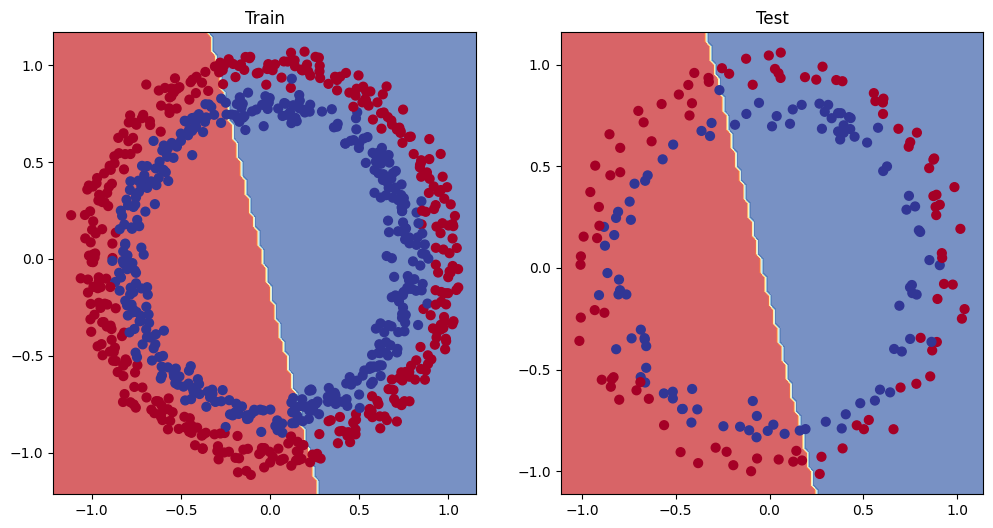

In [49]:
# Plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)